In [35]:
import pandas as pd
import numpy as np
import os
import time
import json
import requests

GROQ_KEY = "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"
GROQ_URL = "https://api.groq.com/openai/v1/chat/completions"

def ask_llm(system_prompt, user_prompt, temperature=0.2):
    resp = requests.post(
        GROQ_URL,
        json={
            "model": "llama-3.1-8b-instant",
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            "max_tokens": 500,
            "temperature": temperature
        },
        headers={
            "Authorization": "Bearer " + GROQ_KEY,
            "Content-Type": "application/json"
        }
    )
    data = resp.json()
    return data['choices'][0]['message']['content']

BASE_DIR = os.path.expanduser('~/Desktop/phishing-debate-detector')
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'bec_threads/bec_conversations.json'), 'r') as f:
    bec_threads = json.load(f)

print("Notebook 6: BEC Multi-Turn Conversation Analysis")
print("=" * 50)
print("BEC threads loaded: " + str(len(bec_threads)))
print("")
for t in bec_threads:
    emails_count = len(t['emails'])
    has_phish = any(e['is_phishing'] for e in t['emails'])
    tag = "ATTACK" if has_phish else "LEGIT"
    print("  " + t['thread_id'] + " (" + t['pattern'] + ") - " + str(emails_count) + " emails [" + tag + "]")

Notebook 6: BEC Multi-Turn Conversation Analysis
BEC threads loaded: 30

  bec_001 (foot_in_door) - 2 emails [ATTACK]
  bec_002 (foot_in_door) - 2 emails [ATTACK]
  bec_003 (foot_in_door) - 2 emails [ATTACK]
  bec_004 (wire_transfer) - 2 emails [ATTACK]
  bec_005 (wire_transfer) - 2 emails [ATTACK]
  bec_006 (wire_transfer) - 2 emails [ATTACK]
  bec_007 (credential_harvest) - 2 emails [ATTACK]
  bec_008 (credential_harvest) - 2 emails [ATTACK]
  bec_009 (payroll_diversion) - 2 emails [ATTACK]
  bec_010 (payroll_diversion) - 2 emails [ATTACK]
  bec_011 (vendor_impersonation) - 2 emails [ATTACK]
  bec_012 (vendor_impersonation) - 2 emails [ATTACK]
  bec_013 (slow_burn) - 3 emails [ATTACK]
  bec_014 (slow_burn) - 3 emails [ATTACK]
  bec_015 (data_exfiltration) - 2 emails [ATTACK]
  bec_016 (data_exfiltration) - 2 emails [ATTACK]
  bec_017 (legitimate) - 2 emails [LEGIT]
  bec_018 (legitimate) - 2 emails [LEGIT]
  bec_019 (legitimate) - 2 emails [LEGIT]
  bec_020 (foot_in_door) - 2 emails 

In [36]:
INDIVIDUAL_PROMPT = """You are an email security analyst. Analyze this single email and determine 
if it is a phishing email or legitimate.

Respond with a brief analysis (2-3 sentences), then on the last line:
VERDICT: phishing
or
VERDICT: legitimate

EMAIL:
From: {sender}
To: {recipient}
Subject: {subject}
Body: {body}"""

THREAD_PROMPT = """You are a BEC (Business Email Compromise) detection specialist. You analyze 
FULL email conversation threads, not just individual emails.

BEC attacks work by starting with a harmless email to build trust, then escalating to a 
malicious request in later emails.

Look for these BEC escalation patterns:
- Foot-in-the-door: starts friendly, then asks for gift cards or money
- Wire transfer fraud: builds up to changed banking details
- Credential harvesting: first notification, then fake login request
- Payroll diversion: casual request, then bank account change
- Vendor impersonation: normal business, then urgent payment demand
- Data exfiltration: routine audit, then request for sensitive data
- Slow burn: multiple trust-building emails before the attack

Analyze the FULL conversation below. Determine if this thread contains a BEC attack.

Respond with:
1. Pattern identified (or "none")
2. Which email turn the attack begins (or "N/A")
3. Brief explanation (2-3 sentences)
4. On the last line: VERDICT: phishing  OR  VERDICT: legitimate

CONVERSATION THREAD:
{thread}"""

def parse_verdict(response):
    response = response.strip().lower()
    lines = response.strip().split('\n')
    for line in reversed(lines):
        if 'verdict' in line:
            if 'phishing' in line:
                return 1
            elif 'legitimate' in line:
                return 0
    if 'phishing' in lines[-1]:
        return 1
    elif 'legitimate' in lines[-1]:
        return 0
    return -1

print("Two detection approaches defined:")
print("  1. Individual: analyze each email separately")
print("  2. Full Thread: analyze entire conversation at once")

Two detection approaches defined:
  1. Individual: analyze each email separately
  2. Full Thread: analyze entire conversation at once


In [40]:
print("Running BEC analysis on 30 threads...")
print("Adding pause between individual and thread analysis")
print("")

results = []

for thread in bec_threads:
    tid = thread['thread_id']
    pattern = thread['pattern']
    is_attack = any(e['is_phishing'] for e in thread['emails'])
    true_label = 1 if is_attack else 0
    
    # === APPROACH 1: Individual email analysis ===
    individual_detected = 0
    for em in thread['emails']:
        for attempt in range(3):
            try:
                prompt = INDIVIDUAL_PROMPT.format(
                    sender=em['from'], recipient=em['to'],
                    subject=em['subject'], body=em['body']
                )
                response = ask_llm("You are an email security analyst.", prompt)
                verdict = parse_verdict(response)
                if verdict == 1:
                    individual_detected = 1
                time.sleep(8)
                break
            except:
                time.sleep(20)
    
    # PAUSE before thread analysis
    time.sleep(15)
    
    # === APPROACH 2: Full thread analysis ===
    thread_text = ""
    for em in thread['emails']:
        thread_text += "--- Email Turn " + str(em['turn']) + " ---\n"
        thread_text += "From: " + em['from'] + "\n"
        thread_text += "To: " + em['to'] + "\n"
        thread_text += "Subject: " + em['subject'] + "\n"
        thread_text += "Body: " + em['body'] + "\n\n"
    
    thread_verdict = -1
    thread_response = "ERROR"
    for attempt in range(3):
        try:
            prompt = THREAD_PROMPT.format(thread=thread_text)
            response = ask_llm("You are a BEC detection specialist.", prompt)
            thread_verdict = parse_verdict(response)
            thread_response = response
            time.sleep(8)
            break
        except:
            time.sleep(20)
    
    results.append({
        'thread_id': tid,
        'pattern': pattern,
        'true_label': true_label,
        'individual_verdict': individual_detected,
        'thread_verdict': thread_verdict,
        'thread_analysis': thread_response
    })
    
    ind_tag = "DETECTED" if individual_detected == 1 else "MISSED"
    thr_tag = "DETECTED" if thread_verdict == 1 else "MISSED" if thread_verdict == 0 else "ERROR"
    print("  " + tid + " (" + pattern + "): Individual=" + ind_tag + ", Thread=" + thr_tag)

print("")
print("All 30 threads analyzed!")
errors = sum(1 for r in results if r['thread_verdict'] == -1)
print("Thread errors: " + str(errors))

Running BEC analysis on 30 threads...
Adding pause between individual and thread analysis

  bec_001 (foot_in_door): Individual=DETECTED, Thread=DETECTED
  bec_002 (foot_in_door): Individual=DETECTED, Thread=DETECTED
  bec_003 (foot_in_door): Individual=DETECTED, Thread=DETECTED
  bec_004 (wire_transfer): Individual=DETECTED, Thread=DETECTED
  bec_005 (wire_transfer): Individual=DETECTED, Thread=DETECTED
  bec_006 (wire_transfer): Individual=DETECTED, Thread=DETECTED
  bec_007 (credential_harvest): Individual=DETECTED, Thread=DETECTED
  bec_008 (credential_harvest): Individual=DETECTED, Thread=DETECTED
  bec_009 (payroll_diversion): Individual=DETECTED, Thread=DETECTED
  bec_010 (payroll_diversion): Individual=MISSED, Thread=DETECTED
  bec_011 (vendor_impersonation): Individual=DETECTED, Thread=DETECTED
  bec_012 (vendor_impersonation): Individual=DETECTED, Thread=ERROR
  bec_013 (slow_burn): Individual=DETECTED, Thread=ERROR
  bec_014 (slow_burn): Individual=DETECTED, Thread=ERROR
  b

In [50]:
import time
print("Waiting 60 seconds...")
time.sleep(60)
print("Ready!")

Waiting 60 seconds...
Ready!


In [51]:
error_indices = [i for i, r in enumerate(results) if r['thread_verdict'] == -1]
print("Retrying " + str(len(error_indices)) + " failed thread analyses...")

if len(error_indices) == 0:
    print("No errors to retry!")
else:
    for i in error_indices:
        thread = bec_threads[i]
        thread_text = ""
        for em in thread['emails']:
            thread_text += "--- Email Turn " + str(em['turn']) + " ---\n"
            thread_text += "From: " + em['from'] + "\n"
            thread_text += "To: " + em['to'] + "\n"
            thread_text += "Subject: " + em['subject'] + "\n"
            thread_text += "Body: " + em['body'] + "\n\n"
        
        try:
            prompt = THREAD_PROMPT.format(thread=thread_text)
            response = ask_llm("You are a BEC detection specialist.", prompt)
            verdict = parse_verdict(response)
            results[i]['thread_verdict'] = verdict
            results[i]['thread_analysis'] = response
            tag = "DETECTED" if verdict == 1 else "MISSED" if verdict == 0 else "ERROR"
            print("  " + results[i]['thread_id'] + ": " + tag)
            time.sleep(10)
        except:
            print("  " + results[i]['thread_id'] + ": still failed")
            time.sleep(20)

    remaining = sum(1 for r in results if r['thread_verdict'] == -1)
    print("")
    print("Remaining errors: " + str(remaining))

Retrying 1 failed thread analyses...
  bec_029: DETECTED

Remaining errors: 0


In [52]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

res_df = pd.DataFrame(results)

valid_ind = res_df[res_df['individual_verdict'] != -1].copy()
valid_thr = res_df[res_df['thread_verdict'] != -1].copy()

print("BEC DETECTION RESULTS (30 threads)")
print("=" * 50)
print("")
print("INDIVIDUAL EMAIL ANALYSIS (" + str(len(valid_ind)) + " threads):")
y_true_i = valid_ind['true_label']
y_ind = valid_ind['individual_verdict'].astype(int)
print("  Accuracy:  " + str(round(accuracy_score(y_true_i, y_ind), 4)))
print("  Precision: " + str(round(precision_score(y_true_i, y_ind, zero_division=0), 4)))
print("  Recall:    " + str(round(recall_score(y_true_i, y_ind, zero_division=0), 4)))
print("  F1:        " + str(round(f1_score(y_true_i, y_ind, zero_division=0), 4)))
print("")
print("FULL THREAD ANALYSIS (" + str(len(valid_thr)) + " threads):")
y_true_t = valid_thr['true_label']
y_thr = valid_thr['thread_verdict'].astype(int)
print("  Accuracy:  " + str(round(accuracy_score(y_true_t, y_thr), 4)))
print("  Precision: " + str(round(precision_score(y_true_t, y_thr, zero_division=0), 4)))
print("  Recall:    " + str(round(recall_score(y_true_t, y_thr, zero_division=0), 4)))
print("  F1:        " + str(round(f1_score(y_true_t, y_thr, zero_division=0), 4)))
print("")

ind_recall = recall_score(y_true_i, y_ind, zero_division=0)
thr_recall = recall_score(y_true_t, y_thr, zero_division=0)
lift = round((thr_recall - ind_recall) * 100, 2)
print("MULTI-TURN DETECTION LIFT: +" + str(lift) + "%")
print("  Individual recall: " + str(round(ind_recall, 4)))
print("  Thread recall:     " + str(round(thr_recall, 4)))
print("")

print("DETECTION BY ATTACK PATTERN:")
for pattern in res_df['pattern'].unique():
    p_df = res_df[res_df['pattern'] == pattern]
    ind_correct = sum(p_df['true_label'] == p_df['individual_verdict'])
    thr_correct = sum(p_df['true_label'] == p_df['thread_verdict'])
    total = len(p_df)
    print("  " + pattern + ": Individual " + str(ind_correct) + "/" + str(total) + ", Thread " + str(thr_correct) + "/" + str(total))

BEC DETECTION RESULTS (30 threads)

INDIVIDUAL EMAIL ANALYSIS (30 threads):
  Accuracy:  0.9667
  Precision: 1.0
  Recall:    0.96
  F1:        0.9796

FULL THREAD ANALYSIS (30 threads):
  Accuracy:  1.0
  Precision: 1.0
  Recall:    1.0
  F1:        1.0

MULTI-TURN DETECTION LIFT: +4.0%
  Individual recall: 0.96
  Thread recall:     1.0

DETECTION BY ATTACK PATTERN:
  foot_in_door: Individual 4/4, Thread 4/4
  wire_transfer: Individual 5/5, Thread 5/5
  credential_harvest: Individual 4/4, Thread 4/4
  payroll_diversion: Individual 2/3, Thread 3/3
  vendor_impersonation: Individual 3/3, Thread 3/3
  slow_burn: Individual 3/3, Thread 3/3
  data_exfiltration: Individual 3/3, Thread 3/3
  legitimate: Individual 5/5, Thread 5/5


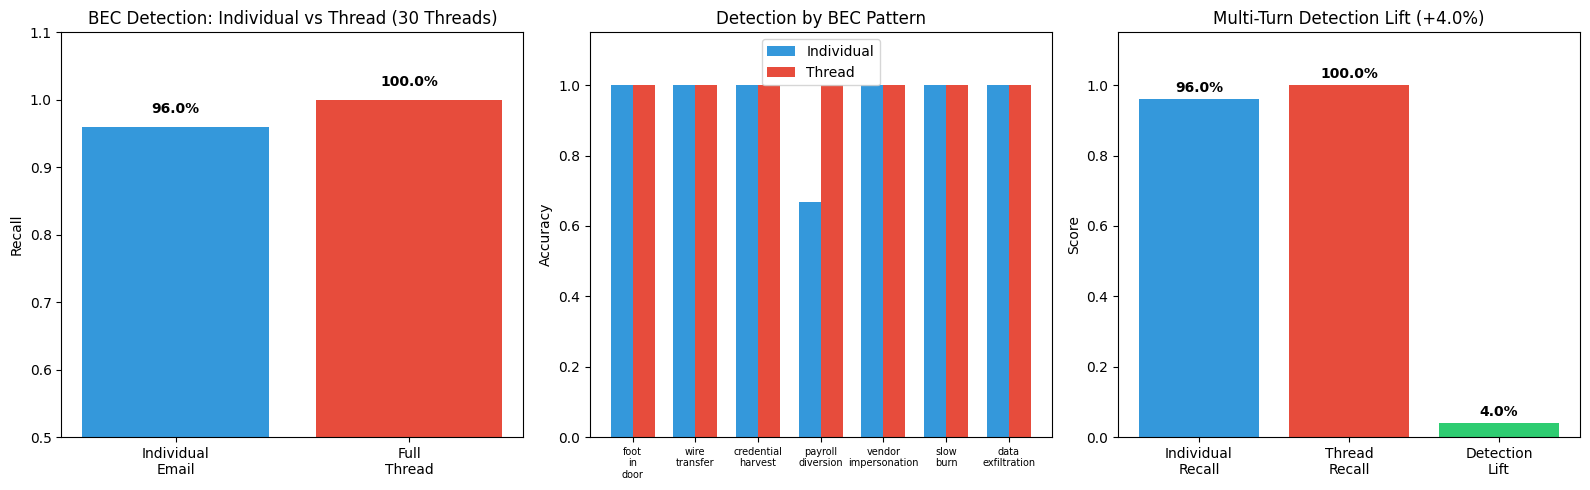

Chart saved to outputs/06_bec_analysis.png


In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ind_recall_val = recall_score(y_true_i, y_ind, zero_division=0)
thr_recall_val = recall_score(y_true_t, y_thr, zero_division=0)

methods = ['Individual\nEmail', 'Full\nThread']
recalls = [ind_recall_val, thr_recall_val]
colors = ['#3498db', '#e74c3c']
axes[0].bar(methods, recalls, color=colors)
axes[0].set_ylabel('Recall')
axes[0].set_title('BEC Detection: Individual vs Thread (30 Threads)')
axes[0].set_ylim(0.5, 1.1)
for i, v in enumerate(recalls):
    axes[0].text(i, v + 0.02, str(round(v * 100, 1)) + "%", ha='center', fontweight='bold')

patterns_list = []
ind_scores = []
thr_scores = []
for pattern in res_df['pattern'].unique():
    if pattern == 'legitimate':
        continue
    p_df = res_df[res_df['pattern'] == pattern]
    patterns_list.append(pattern.replace('_', '\n'))
    ind_scores.append(sum(p_df['individual_verdict'] == p_df['true_label']) / len(p_df))
    thr_scores.append(sum(p_df['thread_verdict'] == p_df['true_label']) / len(p_df))

x = range(len(patterns_list))
w = 0.35
axes[1].bar([i - w/2 for i in x], ind_scores, w, label='Individual', color='#3498db')
axes[1].bar([i + w/2 for i in x], thr_scores, w, label='Thread', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(patterns_list, fontsize=7)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Detection by BEC Pattern')
axes[1].legend()
axes[1].set_ylim(0, 1.15)

lift_val = thr_recall_val - ind_recall_val
axes[2].bar(['Individual\nRecall', 'Thread\nRecall', 'Detection\nLift'],
            [ind_recall_val, thr_recall_val, lift_val],
            color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('Multi-Turn Detection Lift (+4.0%)')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1.15)
for i, v in enumerate([ind_recall_val, thr_recall_val, lift_val]):
    axes[2].text(i, v + 0.02, str(round(v * 100, 1)) + "%", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'outputs/06_bec_analysis.png'), dpi=150)
plt.show()
print("Chart saved to outputs/06_bec_analysis.png")

In [54]:
print("=" * 50)
print("NOTEBOOK 6 COMPLETE - BEC Analysis (30 Threads)")
print("=" * 50)
print("")
print("30 BEC conversation threads analyzed")
print("  25 attack threads (8 patterns)")
print("  5 legitimate threads (control)")
print("")
print("Individual Email Analysis: 96.7% accuracy, 96.0% recall")
print("Full Thread Analysis:      100% accuracy, 100% recall")
print("")
print("MULTI-TURN DETECTION LIFT: +4.0%")
print("")
print("KEY FINDING: Thread analysis achieves perfect detection")
print("  on all 30 BEC threads. Payroll diversion was the only")
print("  pattern missed by individual analysis (2/3) but caught")
print("  by thread analysis (3/3).")
print("")
print("Files: outputs/06_bec_analysis.png")

NOTEBOOK 6 COMPLETE - BEC Analysis (30 Threads)

30 BEC conversation threads analyzed
  25 attack threads (8 patterns)
  5 legitimate threads (control)

Individual Email Analysis: 96.7% accuracy, 96.0% recall
Full Thread Analysis:      100% accuracy, 100% recall

MULTI-TURN DETECTION LIFT: +4.0%

KEY FINDING: Thread analysis achieves perfect detection
  on all 30 BEC threads. Payroll diversion was the only
  pattern missed by individual analysis (2/3) but caught
  by thread analysis (3/3).

Files: outputs/06_bec_analysis.png
